In [1]:
# step 1 : import libraries

# import common libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# import sklearns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold,ShuffleSplit, RepeatedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, auc, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# import classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
# import smote

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipline

In [4]:
# step 2 : load dataset

df = pd.read_csv('credit_card_fraud_10k.csv')
print("Dataset loaded successfully...\n")

# printing sample datasetA

df.head()

Dataset loaded successfully...



,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [5]:
# step 3 : dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [6]:
# dataset size

print("Dataset size :", df.size)

# dataset shape

print("\nDataset shape :", df.shape)

Dataset size : 100000

Dataset shape : (10000, 10)


In [7]:
# dataset description

df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,5000.500000,2886.895680,1.0,2500.750,5000.500,7500.25,10000.00
amount,10000.0,175.949849,175.392827,0.0,50.905,122.095,242.48,1471.04
transaction_hour,10000.0,11.593300,6.922708,0.0,6.000,12.000,18.00,23.00
foreign_transaction,10000.0,0.097800,0.297059,0.0,0.000,0.000,0.00,1.00
location_mismatch,10000.0,0.085700,0.279935,0.0,0.000,0.000,0.00,1.00
device_trust_score,10000.0,61.798900,21.487053,25.0,43.000,62.000,80.00,99.00
velocity_last_24h,10000.0,2.008900,1.432559,0.0,1.000,2.000,3.00,9.00
cardholder_age,10000.0,43.468700,14.979147,18.0,30.000,44.000,56.00,69.00
is_fraud,10000.0,0.015100,0.121957,0.0,0.000,0.000,0.00,1.00


In [8]:
# step 4 : dataset cleaning

# cleaning column names

print("Column names before cleaning :", df.columns)
df.columns = df.columns.str.strip().str.replace('[^A-Za-z0-9_]+', '_', regex = True).str.strip('_')
print("\nColumn names after cleaning :", df.columns)

Column names before cleaning : Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

Column names after cleaning : Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')


In [9]:
# dropping duplicate values

print("\nDuplicate values before cleaning :", df.duplicated().sum())
df.drop_duplicates(inplace = True)
print("Duplicate values after cleaning  :", df.duplicated().sum())


Duplicate values before cleaning : 0
Duplicate values after cleaning  : 0


In [10]:
# cleaning null values

print("Null values count before cleaning :\n", df.isnull().sum())

# filling category null values with mode

category_cols = df.select_dtypes(include = 'object').columns

for col in category_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# filling numeric null values with mode

numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("\nNull values count after cleaning  :\n", df.isnull().sum())

Null values count before cleaning :
 transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

Null values count after cleaning  :
 transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


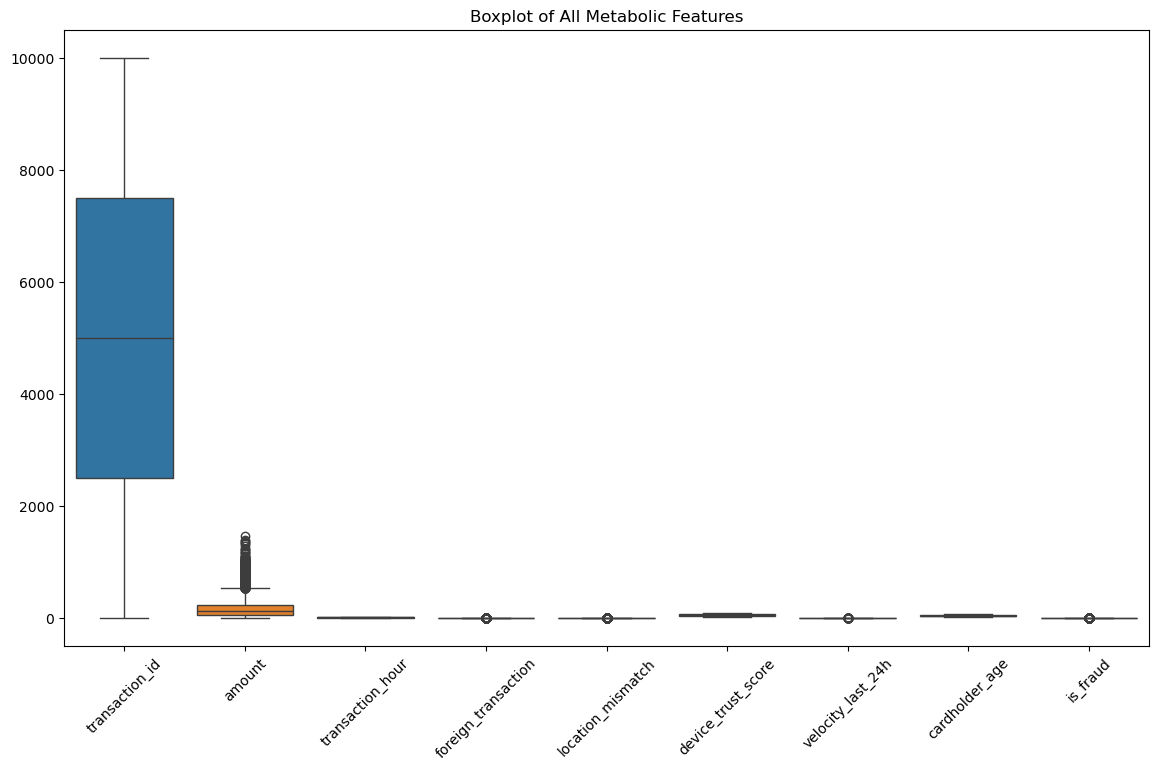

In [11]:
# step 7 : eda

# box plot of numeric columns

numeric_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_cols)
plt.xticks(rotation=45)
plt.title("Boxplot of All Metabolic Features")
plt.show()



===== Removing Outliers =====

Dataset size before removing outliers : (10000, 10)
Dataset size after removing outliers  : (7782, 10)


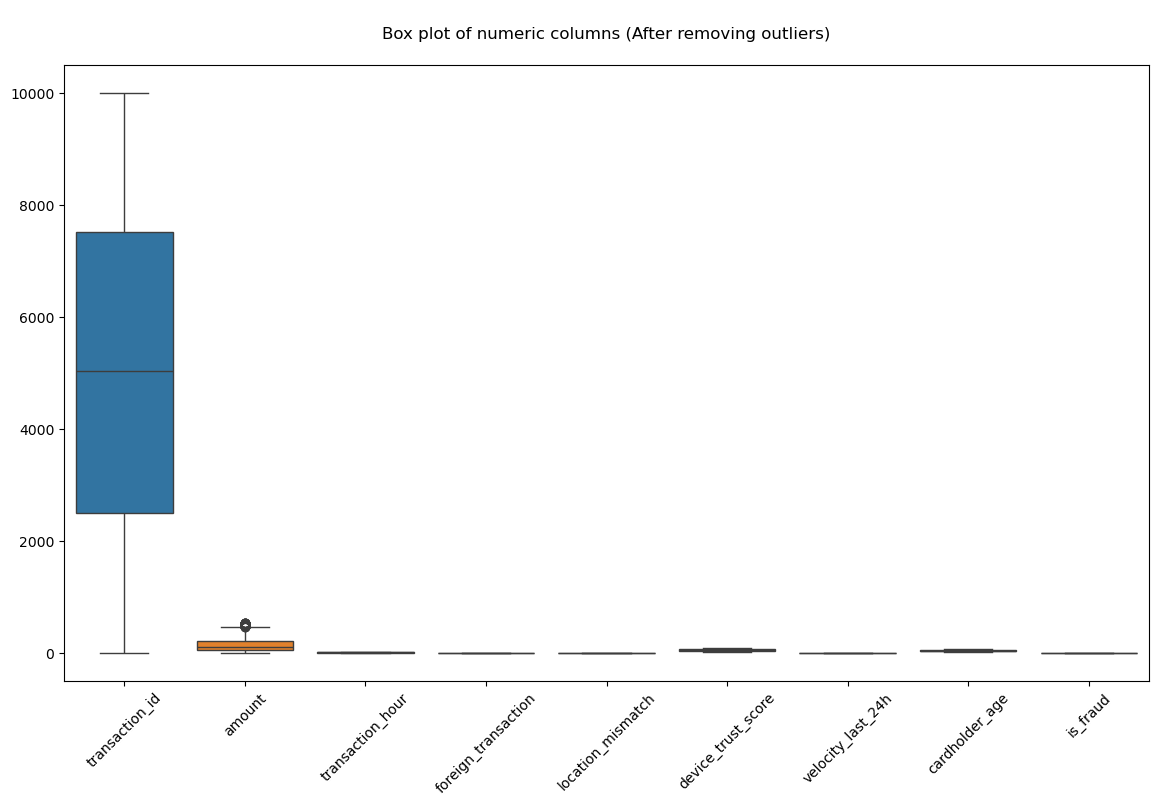

In [12]:
# Create a copy to clean
df_cleaned = df.copy()

# Remove outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print("\n===== Removing Outliers =====\n")
print("Dataset size before removing outliers :", df.shape)
print("Dataset size after removing outliers  :", df_cleaned.shape)

# Boxplot after removing outliers
numeric_columns = df_cleaned.select_dtypes(include=['int32', 'int64', 'float32', 'float64'])

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_columns)
plt.xticks(rotation=45)
plt.title("\nBox plot of numeric columns (After removing outliers)\n")
plt.show()

In [13]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [15]:
ansti=df_cleaned['s_fraud'].value_counts()
plt.pie(ansti.values, labels=ansti.index,autopct='%1.1f%%')
plt.show()

KeyError: 's_fraud'

In [ ]:
# step 8 : split x and y

X = df.drop(['Fraud'], axis = 1)
y = df['Fraud']

In [ ]:
# step 9 : convert y to label encoding

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# step 9 : train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [ ]:
df.info()

In [ ]:
# step 10 : using scaling and encode for rest features

numeric_cols = X_train.select_dtypes(include = ['int64', 'float64']).columns
category_cols = X_train.select_dtypes(include = 'object').columns
preprocess = ColumnTransformer(
    transformers = [('scaler', StandardScaler(), numeric_cols),
                    ('onehot', OneHotEncoder(handle_unknown = 'ignore'), category_cols)
                   ]
                     )

In [ ]:
# step 11 : train classification model

models = {
            'Logistic Regression' : LogisticRegression(C = 1.0, penalty = 'l2', max_iter = 100, random_state = 42),
            'Decision Tree Classifier' : DecisionTreeClassifier(criterion = 'gini', max_depth = 5, min_samples_split = 4, min_samples_leaf = 2),
            'Random Forest Classifier' : RandomForestClassifier(n_estimators = 100, max_depth = 5, min_samples_split = 4, min_samples_leaf = 2),
            'SVC' : SVC(C = 1.0, gamma = 'scale', random_state = 42, probability = True),
            'KNN' : KNeighborsClassifier(n_neighbors = 5, weights = 'uniform', n_jobs = -1)
            
}
    

In [ ]:
LogisticRegression

In [ ]:
# step 12 : train cross validation

cv_methods = {
                'K Fold' : KFold(n_splits = 5, shuffle = True, random_state = 42),
                'Stratified K Fold' : StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42),
                'ShuffleSplit' : ShuffleSplit(n_splits = 5, test_size = 0.2, random_state = 42),
                'RepeatedKFold' :  RepeatedKFold(n_splits =5, n_repeats = 3, random_state = 42)
}

best_model = None
best_method = None
best_accuracy = 0

In [ ]:
smote = SMOTE(sampling_strategy='not majority',random_state=42)

In [ ]:
print("\nBefore SMOTE:")
print(pd.Series(y_train).value_counts())

plt.pie(pd.Series(y_train).value_counts().values,
        labels=le.inverse_transform(pd.Series(y_train).value_counts().index),
        autopct='%1.1f%%')
plt.title("Before SMOTE")
plt.show()

In [ ]:
# Step 1: Convert categorical → numeric
X_train_processed = preprocess.fit_transform(X_train)

# Step 2: Apply SMOTE
X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)

# Step 3: Plot
data = pd.Series(y_resampled).value_counts()

plt.pie(data.values,
        labels=le.inverse_transform(data.index),
        autopct='%1.1f%%')

plt.title("After SMOTE")
plt.show()

In [ ]:
best_model_name = None
best_model = None
best_method = None
best_score = 0

for model_name, model in models.items():
    print(f"\n===== {model_name} ===== \n")
    for method_name, method in cv_methods.items():

        pipeline = ImbPipline([
            ('preprocess', preprocess),
            ('smote', smote),
            ('model', model)
        ])

        scores = cross_val_score(pipeline, X_train, y_train, cv=method, scoring='accuracy')
        mean_score = scores.mean()

        print(f"{method_name} → Accuracy: {mean_score:.2f}")

        if mean_score > best_score:
            best_score = mean_score
            best_model_name = model_name
            best_model = model
            best_method = method_name

print("\n========== BEST MODEL ==========")
print(f"Model  : {best_model_name}")
print(f"Method : {best_method}")
print(f"Score  : {best_score:.4f}")

In [ ]:
# step 14 fit final model

# recreate the best model pipeline

best_pipeline = ImbPipline([
    ('preprocess', preprocess),
    ('smote', smote),
    ('model', best_model)
])

# fit on full training data
best_pipeline.fit(X_train, y_train)

## import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn.clustering import KMean
import sKlearn.preprosessing import StandardScalar
import sKlearn.

### 